In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.metrics         import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

# (i)  READ DATASET INTO DATAFRAME
df = pd.read_csv('student_performance.csv')
print(" Dataset Loaded")
print(df.head(5).to_string(index=False))
print(f"\n  Shape   : {df.shape}")
print(f"  Columns : {list(df.columns)}")
print("\n  Target Distribution:")
print(df['result'].value_counts().to_string())
print("\n  Statistical Summary:")
print(df.describe().round(2))

 Dataset Loaded
 attendance  study_hrs  assignment_avg  midterm_score  lab_score  participation  sleep_hrs  parent_edu result
         88        9.5              44             67         61              3        5.0           2   Pass
         78        3.9              86             37         53              5        5.5           1   Fail
         64        5.7              88             94         65              5        8.5           2   Pass
         92        7.3              69             46         67              5        4.1           1   Pass
         57        4.3              85             74         62              3        4.4           1   Pass

  Shape   : (200, 9)
  Columns : ['attendance', 'study_hrs', 'assignment_avg', 'midterm_score', 'lab_score', 'participation', 'sleep_hrs', 'parent_edu', 'result']

  Target Distribution:
result
Pass    130
Fail     70

  Statistical Summary:
       attendance  study_hrs  assignment_avg  midterm_score  lab_score  \
count  

In [4]:
# (ii)  SEPARATE FEATURES and TARGET

features = ['attendance', 'study_hrs', 'assignment_avg','midterm_score', 'lab_score', 'participation','sleep_hrs', 'parent_edu']
X = df[features]
y = df['result']               # Pass / Fail

# Encode target: Pass=1, Fail=0
le = LabelEncoder()
y_enc = le.fit_transform(y)    # Fail=0, Pass=1

print(" Features and Target Separated")

print(f"  Input Features ({len(features)}): {features}")
print(f"  Target                  : result  (Pass / Fail)")
print(f"  Encoded                 : Fail=0 , Pass=1")

# Standardize features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

 Features and Target Separated
  Input Features (8): ['attendance', 'study_hrs', 'assignment_avg', 'midterm_score', 'lab_score', 'participation', 'sleep_hrs', 'parent_edu']
  Target                  : result  (Pass / Fail)
  Encoded                 : Fail=0 , Pass=1


In [5]:
# (iii)  SPLIT DATASET — three ratios
splits = {
    '70:30': train_test_split(X_scaled, y_enc, test_size=0.30, random_state=42),
    '60:40': train_test_split(X_scaled, y_enc, test_size=0.40, random_state=42),
    '80:20': train_test_split(X_scaled, y_enc, test_size=0.20, random_state=42),
}

print(" Train-Test Split Sizes")
print(f"  {'Ratio':<10} {'Train':<12} {'Test'}")
print("  " + "-" * 32)
for ratio, (Xtr, Xte, ytr, yte) in splits.items():
    print(f"  {ratio:<10} {len(Xtr):<12} {len(Xte)}")

 Train-Test Split Sizes
  Ratio      Train        Test
  --------------------------------
  70:30      140          60
  60:40      120          80
  80:20      160          40


In [6]:
# (iv)  FIND BEST VALUE OF K using cross-validation

print(" Finding Best K Value (Cross-Validation on 70:30 split)")
X_train_70, X_test_70, y_train_70, y_test_70 = splits['70:30']
k_range  = range(1, 21)
cv_scores = []

for k in k_range:
    knn  = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_70, y_train_70, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f"\n  {'K':<6} {'CV Accuracy':>12}")
print("  " + "-" * 20)
for k, sc in zip(k_range, cv_scores):
    marker = " ← Best K" if k == best_k else ""
    print(f"  {k:<6} {sc*100:>10.2f}%{marker}")

print(f"\n   Best K = {best_k}  (Accuracy = {max(cv_scores)*100:.2f}%)")

 Finding Best K Value (Cross-Validation on 70:30 split)

  K       CV Accuracy
  --------------------
  1           80.71%
  2           77.14%
  3           78.57%
  4           78.57%
  5           81.43%
  6           77.86%
  7           82.86%
  8           82.14%
  9           82.86%
  10          84.29%
  11          84.29%
  12          84.29%
  13          82.86%
  14          84.29%
  15          84.29%
  16          83.57%
  17          82.86%
  18          85.00% ← Best K
  19          82.14%
  20          83.57%

   Best K = 18  (Accuracy = 85.00%)


In [7]:
# (v)  TRAIN KNN and CLASSIFY TEST SAMPLES for all splits

print(f"   KNN (K={best_k}) — Training & Classification")

models  = {}
results = {}

for ratio, (X_train, X_test, y_train, y_test) in splits.items():
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    models[ratio]  = (knn, X_test, y_test, y_pred)
    results[ratio] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1'       : f1_score(y_test, y_pred, zero_division=0),
        'CM'       : confusion_matrix(y_test, y_pred)
    }
    print(f"\n   Trained and tested on split {ratio}")

   KNN (K=18) — Training & Classification

   Trained and tested on split 70:30

   Trained and tested on split 60:40

   Trained and tested on split 80:20


In [8]:
# (vi)  EVALUATE — Metrics + Confusion Matrix for all splits

print(" Evaluation Metrics")


print(f"\n  {'Metric':<12} {'70:30':>10} {'60:40':>10} {'80:20':>10}")
print("  " + "-" * 46)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1']:
    row = f"  {metric:<12}"
    for ratio in splits:
        row += f"  {results[ratio][metric]*100:>7.2f}%"
    print(row)

# Detailed report + confusion matrix for 70:30
_, X_test_70, y_test_70, y_pred_70 = models['70:30']
cm_70 = results['70:30']['CM']
TN, FP, FN, TP = cm_70.ravel()

print("\n   Detailed Report for 70:30 split ")
print(classification_report(y_test_70, y_pred_70,
      target_names=['Fail (0)', 'Pass (1)']))

print(f"  Confusion Matrix (70:30):")
print(f"             Predicted              ")
print(f"             Fail  |  Pass          ")
print(f"   Actual                           ")
print(f"   Fail    TN={TN:>3}  FP={FP:>3}   ")
print(f"   Pass    FN={FN:>3}  TP={TP:>3}   ")

 Evaluation Metrics

  Metric            70:30      60:40      80:20
  ----------------------------------------------
  Accuracy        88.33%    86.25%    90.00%
  Precision       88.10%    86.21%    86.21%
  Recall          94.87%    94.34%   100.00%
  F1              91.36%    90.09%    92.59%

   Detailed Report for 70:30 split 
              precision    recall  f1-score   support

    Fail (0)       0.89      0.76      0.82        21
    Pass (1)       0.88      0.95      0.91        39

    accuracy                           0.88        60
   macro avg       0.88      0.86      0.87        60
weighted avg       0.88      0.88      0.88        60

  Confusion Matrix (70:30):
             Predicted              
             Fail  |  Pass          
   Actual                           
   Fail    TN= 16  FP=  5   
   Pass    FN=  2  TP= 37   


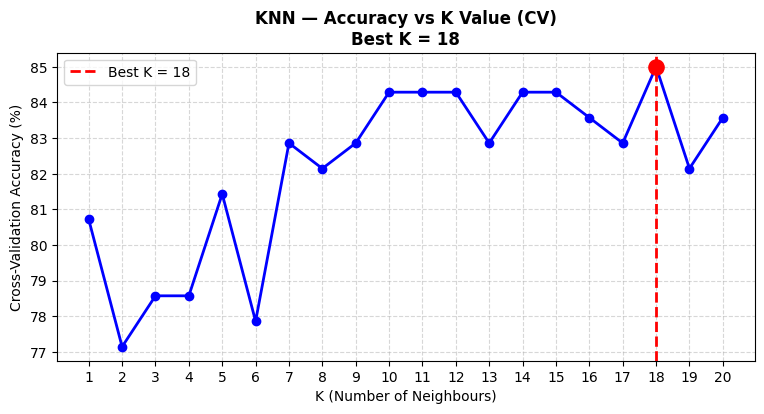

In [9]:




# PLOT 1 : Best K selection curve

plt.figure(figsize=(9, 4))
plt.plot(k_range, [s*100 for s in cv_scores], 'bo-',
         linewidth=2, markersize=6)
plt.axvline(best_k, color='red', linestyle='--', linewidth=2,
            label=f'Best K = {best_k}')
plt.scatter([best_k], [max(cv_scores)*100], color='red', s=120, zorder=5)
plt.title(f'KNN — Accuracy vs K Value (CV)\nBest K = {best_k}',
          fontsize=12, fontweight='bold')
plt.xlabel('K (Number of Neighbours)')
plt.ylabel('Cross-Validation Accuracy (%)')
plt.xticks(k_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

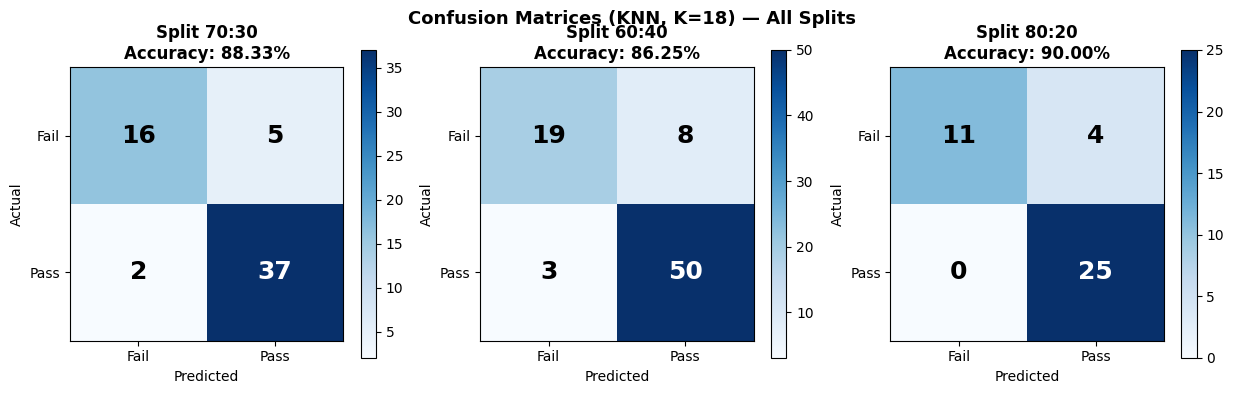

In [14]:
# PLOT 2 : Confusion Matrices for all 3 splits

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Confusion Matrices (KNN, K={best_k}) — All Splits',fontsize=13, fontweight='bold')

for ax, ratio in zip(axes, splits):
    cm    = results[ratio]['CM']
    im    = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'Split {ratio}\nAccuracy: {results[ratio]["Accuracy"]*100:.2f}%', fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Fail', 'Pass'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Fail', 'Pass'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=18, fontweight='bold',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.colorbar(im, ax=ax)

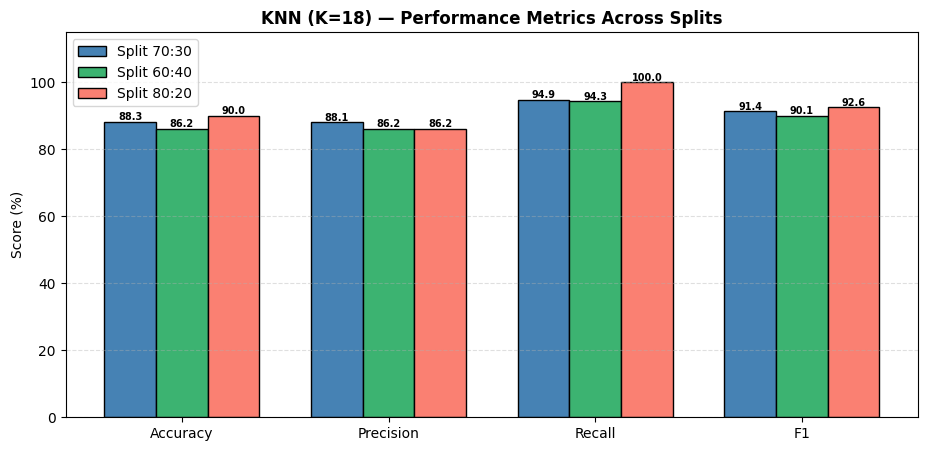

In [11]:
# PLOT 3 : Metrics bar chart comparing all 3 splits

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
ratio_labels = list(splits.keys())
x = np.arange(len(metric_names))
width = 0.25
colors = ['steelblue', 'mediumseagreen', 'salmon']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (ratio, color) in enumerate(zip(ratio_labels, colors)):
    vals = [results[ratio][m]*100 for m in metric_names]
    bars = ax.bar(x + (i-1)*width, vals, width,
                  label=f'Split {ratio}', color=color, edgecolor='black')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f'{v:.1f}', ha='center', fontsize=7, fontweight='bold')

ax.set_title(f'KNN (K={best_k}) — Performance Metrics Across Splits',
             fontsize=12, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metric_names)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

In [16]:
# (vii)  PREDICT for NEW STUDENT DATA
print(" Predict Result for New Student\n")
print("  (parent_edu: 1=School, 2=UG, 3=PG)\n")

# Use the 70:30 trained model
best_model = models['70:30'][0]
try:
    att  = float(input("  Attendance (%)        : "))
    stdy = float(input("  Study Hours/day       : "))
    asgn = float(input("  Assignment Avg        : "))
    mid  = float(input("  Midterm Score         : "))
    lab  = float(input("  Lab Score             : "))
    part = float(input("  Participation (1-10)  : "))
    slp  = float(input("  Sleep Hours           : "))
    edu  = float(input("  Parent Education      : "))

    new_student = scaler.transform([[att, stdy, asgn, mid, lab, part, slp, edu]])
    pred_enc    = best_model.predict(new_student)[0]
    pred_proba  = best_model.predict_proba(new_student)[0]
    pred_label  = le.inverse_transform([pred_enc])[0]

    print(f"\n   Predicted Result : {' PASS' if pred_label == 'Pass' else ' FAIL'}")
    print(f"  Probability — Fail : {pred_proba[0]*100:.2f}%")
    print(f"  Probability — Pass : {pred_proba[1]*100:.2f}%")

except Exception:
    samples = [
        [92, 8.0, 88, 85, 90, 9, 7.5, 3],   # strong student → Pass
        [55, 2.0, 45, 38, 50, 2, 5.0, 1],   # weak student   → Fail
    ]
    labels = ["High-performer", "Low-performer"]
    print("  (Non-interactive — sample predictions)\n")
    for s, lbl in zip(samples, labels):
        ns   = scaler.transform([s])
        pred = best_model.predict(ns)[0]
        prob = best_model.predict_proba(ns)[0]
        res  = le.inverse_transform([pred])[0]
        print(f"  {lbl}: {dict(zip(features, s))}")
        print(f"  → Predicted: {' PASS' if res=='Pass' else ' FAIL'}"
              f"  |  Fail: {prob[0]*100:.1f}%  Pass: {prob[1]*100:.1f}%\n")

 Predict Result for New Student

  (parent_edu: 1=School, 2=UG, 3=PG)



  Attendance (%)        :  93
  Study Hours/day       :  7.5
  Assignment Avg        :  76
  Midterm Score         :  81
  Lab Score             :  92
  Participation (1-10)  :  4
  Sleep Hours           :  6
  Parent Education      :  2



   Predicted Result :  PASS
  Probability — Fail : 0.00%
  Probability — Pass : 100.00%


C:\Users\kSaty\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
